In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [3]:
X,y=make_blobs(n_samples=100,centers=3,n_features=2)

In [4]:
X

array([[-1.20306324, -6.20442847],
       [-3.12257929, -4.85311856],
       [-6.01170582, -6.57715916],
       [-1.8432804 , -2.7010644 ],
       [ 5.45898671,  2.02668542],
       [-1.62396051, -4.2606315 ],
       [-3.46475291, -5.1547163 ],
       [-2.54822304, -4.83890286],
       [ 5.96837848,  2.89009593],
       [-2.57539498, -4.31864825],
       [ 6.70460083,  3.66140719],
       [-6.60192517, -5.45298918],
       [-6.89062287, -2.42869883],
       [-2.72297215, -6.34320656],
       [-2.57960635, -4.08819107],
       [ 6.4812093 ,  3.58380647],
       [ 6.36925266,  2.41185901],
       [-5.4163517 , -4.13542186],
       [-3.65655624, -3.35234835],
       [ 6.05527649,  2.3910868 ],
       [-2.61797756, -3.82942422],
       [-6.52813369, -4.98201224],
       [ 4.43647128,  3.14223627],
       [-7.75324989, -4.56851624],
       [-6.49267984, -4.30279676],
       [-4.29944878, -5.57280335],
       [ 5.71885373,  2.6186043 ],
       [-6.34023435, -5.28755494],
       [ 5.94151354,

In [6]:
y

array([0, 0, 2, 0, 1, 0, 0, 0, 1, 0, 1, 2, 2, 0, 0, 1, 1, 2, 0, 1, 0, 2,
       1, 2, 2, 0, 1, 2, 1, 2, 1, 1, 0, 2, 2, 0, 1, 0, 1, 2, 0, 0, 1, 2,
       0, 1, 1, 0, 2, 2, 2, 2, 0, 0, 0, 1, 2, 0, 1, 0, 0, 0, 2, 1, 1, 2,
       2, 1, 0, 1, 2, 1, 1, 1, 1, 2, 2, 1, 2, 0, 1, 2, 1, 2, 1, 1, 1, 1,
       0, 2, 2, 0, 0, 2, 2, 2, 2, 0, 0, 0])

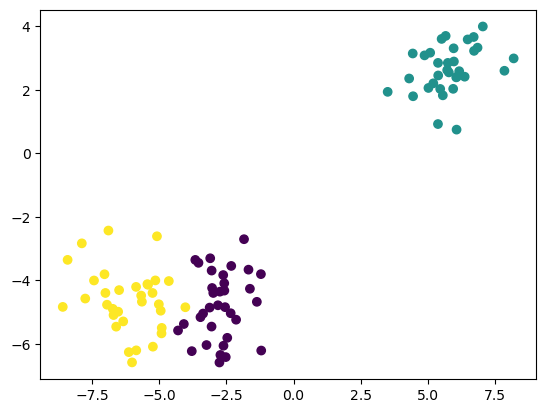

In [11]:
plt.scatter(X[:,0],X[:,1],c=y)
plt.show()

In [14]:
### standardization 
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [17]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [19]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [20]:
from sklearn.cluster import KMeans

In [26]:
### elbow method to select k values
import warnings
warnings.filterwarnings('ignore')

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)


In [27]:
wcss

[160.00000000000006,
 14.336838016818735,
 7.83856330191915,
 5.978115900441968,
 4.9838911731087565,
 4.575754633900105,
 3.980021041017557,
 3.4878881842845706,
 2.6669609193223773,
 2.2980529269853123]

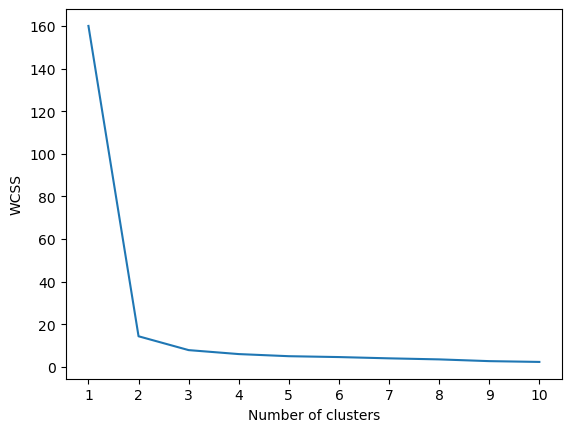

In [28]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()


In [29]:
### so here the values becomes stable after three so for n_clusters=3 we will get the best values


In [31]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)

In [32]:
kmeans.fit_predict(X_train_scaled)

array([1, 0, 1, 1, 1, 1, 0, 2, 0, 1, 2, 0, 1, 1, 2, 0, 2, 2, 0, 1, 2, 2,
       0, 2, 2, 1, 2, 0, 2, 0, 2, 0, 2, 1, 1, 2, 0, 1, 1, 2, 2, 0, 0, 2,
       2, 1, 1, 0, 0, 0, 0, 0, 1, 2, 0, 0, 2, 0, 2, 0, 1, 1, 0, 2, 0, 0,
       2, 2, 2, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 2])

In [34]:
y_pred=kmeans.predict(X_test_scaled)

In [35]:
y_pred

array([2, 0, 2, 1, 0, 2, 1, 1, 1, 0, 0, 1, 1, 2, 0, 1, 2, 1, 2, 1])

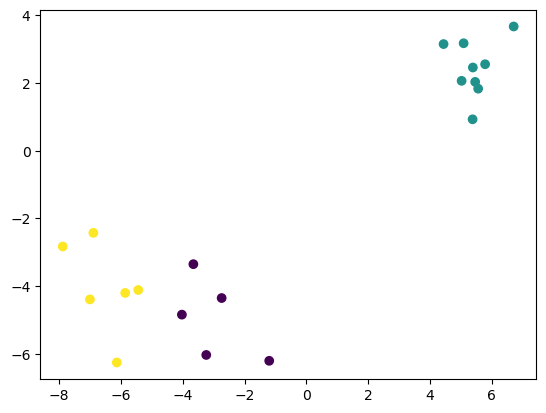

In [37]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)
plt.show()

### validating the k value
## 1. kneelocator
### 2. silhoustte scoring

In [40]:
### kneelocator
import warnings
warnings.filterwarnings('ignore')
!pip install kneed

Defaulting to user installation because normal site-packages is not writeable


In [42]:
from kneed import KneeLocator
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")




In [45]:
kl.elbow

2

In [47]:
### silhouste scoring
from sklearn.metrics import silhouette_score


In [53]:
silhuoette_coefficient=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhuoette_coefficient.append(score)


In [55]:
silhuoette_coefficient


[0.8195654378535095,
 0.577137683463726,
 0.5344044298905741,
 0.3948546669621012,
 0.3890723347739974,
 0.33014929095269985,
 0.37425476433552646,
 0.3197943794553784,
 0.3551483131800975]

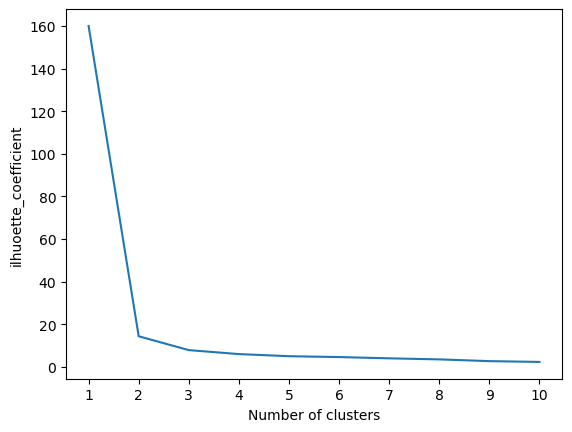

In [60]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of clusters")
plt.ylabel("ilhuoette_coefficient")
plt.show()
